## Colab Setup

For Notebook 6 - Deep Learning - Use GPU in Colab

> Runtime

> Change Runtime Type

> T4 GPU

> Save

In [25]:
import os, sys, importlib

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    REPO_URL  = "https://github.com/tackes/Modern-Time-Series-Forecasting-Cohort.git"
    REPO_PATH = "/content/packt-modern-time-series"

    if not os.path.exists(REPO_PATH):
        os.system(f"git clone -q {REPO_URL} {REPO_PATH}")

    # Stay in instructor_notebooks so Path().resolve().parent resolves to repo root
    os.chdir(f"{REPO_PATH}/instructor_notebooks")

    if REPO_PATH not in sys.path:
        sys.path.insert(0, REPO_PATH)

    # Colab already has GPU torch — only install CPU build if torch is missing
    if importlib.util.find_spec("torch") is None:
        os.system("pip install -q torch --index-url https://download.pytorch.org/whl/cpu")
    os.system("pip install -q neuralforecast")

print(f"✓ Setup complete — {os.getcwd()}")

✓ Setup complete — c:\Users\tacke\Documents\packt-modern-time-series\instructor_notebooks


# Module 6 — Deep Learning with NHITS
**Type:** [Code With Me]  
**Time:** 40 minutes  
**Job:** Implement a global neural forecasting model (NHITS). Compare it against the LightGBM and baseline floors. Be honest about what deep learning adds — and what it costs.



---
## 6.1 — Setup
**[Watch Only]**

---

In [26]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import json
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

matplotlib.rcParams['figure.figsize'] = (14, 4)
matplotlib.rcParams['axes.spines.top'] = False
matplotlib.rcParams['axes.spines.right'] = False

from neuralforecast import NeuralForecast
from neuralforecast.models import NHITS

from config import (
    ARTIFACT_DIR,
    PARAMS_DIR,
    HORIZON,
    N_WINDOWS,
    STEP_SIZE,
    REFIT,
    MICRO_SUBSET_N,
    WORKSHOP_SUBSET_N,
    RANDOM_SEED,
    USE_TUNED_PARAMS,
)
from src.checkpointing import load_checkpoint
from src.evaluation import score_forecasts, build_leaderboard
from src.schemas import validate_forecast
from src.forecast_schema import reshape_neuralforecast_cv
from src.plotting import plot_forecast_overlay

print("Setup complete.")

Setup complete.


---
## 6.2 — Load Panel and Micro Subset
**[Watch Only]**

---

In [27]:
panel = load_checkpoint("03_validated_panel")

top_series = (
    panel.groupby("unique_id")["y"]
    .sum()
    .sort_values(ascending=False)
    .head(MICRO_SUBSET_N)
    .index
)
micro = panel[panel["unique_id"].isin(top_series)].copy()

print(f"Micro panel: {micro['unique_id'].nunique()} series, {len(micro):,} rows")


  ✓ RED PATH RECOVERY COMPLETE
    Artifact : 03_validated_panel
    File     : 03_validated_panel.parquet
    Rows     : 1,941,000

Micro panel: 50 series, 97,050 rows


---
## 6.3 — Why NHITS?
**[Watch Only]**


**NHITS is a global neural model** — trains across all series simultaneously, producing the full 28-step horizon in a single forward pass.

**How it differs from LightGBM:**
- Uses hierarchical pooling to capture patterns at multiple temporal scales
- No recursive error accumulation — the full horizon is one forward pass
- Captures non-linear interactions that fixed lag windows miss

**What it costs:**
- Gradient training — not as trivially parallelizable as tree boosting
- Higher hyperparameter sensitivity: `max_steps`, `input_size`, and learning rate all affect stability
- No built-in feature importances; interpretability is lower than a tree model

> **Key idea:** NHITS earns its keep when demand has complex multi-scale dependencies (long promotional build-ups, stacked seasonality). For stable weekly seasonal demand, LightGBM often wins the ROI calculation.

---
## 6.4 — Load NHITS Parameters
**[Watch Only]**

---

In [28]:
params_path = PARAMS_DIR / "nhits_tuned.json"
with open(params_path) as f:
    nhits_params = json.load(f)

nhits_params = {k: v for k, v in nhits_params.items() if not k.startswith("_")}
nhits_params["random_seed"] = RANDOM_SEED
nhits_params["h"] = HORIZON

print(f"Loaded {len(nhits_params)} params from: nhits_tuned.json")
print(f"  max_steps = {nhits_params['max_steps']} — reduce to 200 if training > 90 seconds")

Loaded 11 params from: nhits_tuned.json
  max_steps = 500 — reduce to 200 if training > 90 seconds


---
## 6.5 — Configure NHITS
**[Code With Me — 2 lines]**

Fill in `input_size` and `max_steps` from the `nhits_params` dict loaded above.

**Instructor cue:** Emphasize that deep learning is not just a better model class — it also introduces hardware, runtime, and training-budget decisions.

---

In [29]:
nhits_model = NHITS(
    h=nhits_params["h"],
    input_size=nhits_params["input_size"],    # Instructor: students fill this to connect lookback length to available history.
    max_steps=nhits_params["max_steps"],      # Instructor: students fill this to connect neural training budget to runtime.
    val_check_steps=nhits_params["val_check_steps"],
    early_stop_patience_steps=nhits_params["early_stop_patience_steps"],
    n_freq_downsample=nhits_params["n_freq_downsample"],
    learning_rate=nhits_params["learning_rate"],
    batch_size=nhits_params["batch_size"],
    random_seed=nhits_params["random_seed"],
    enable_progress_bar=nhits_params["enable_progress_bar"],
    enable_model_summary=nhits_params["enable_model_summary"],
)

nf = NeuralForecast(models=[nhits_model], freq="D")

print(f"NeuralForecast configured.")
print(f"  Model       : NHITS")
print(f"  h           : {nhits_params['h']}")
print(f"  input_size  : {nhits_params['input_size']}")
print(f"  max_steps   : {nhits_params['max_steps']}")

Seed set to 42


NeuralForecast configured.
  Model       : NHITS
  h           : 28
  input_size  : 84
  max_steps   : 500


**Expected output:**
```
NeuralForecast configured.
  Model       : NHITS
  h           : 28
  input_size  : 56
  max_steps   : 300
```

---
## 6.6 — Run Cross-Validation on the Micro Subset
**[Watch Only]**

> **⚠ Runtime warning:** Target < 60 seconds. Hard ceiling 90 seconds. If this cell approaches 90 seconds, interrupt it (`I, I` in Jupyter / square stop button in Colab) and run the Red Path in 6.7.

---

In [30]:
%%time
# Target: < 60 s | Hard ceiling: 90 s — interrupt (I, I) and run 6.7 if needed
cv_dl_micro = nf.cross_validation(
    df=micro,
    n_windows=N_WINDOWS,
    step_size=STEP_SIZE,
    refit=REFIT,
)

print(f"NHITS CV complete: {cv_dl_micro.shape[0]:,} rows × {cv_dl_micro.shape[1]} columns")
cv_dl_micro.head(3)
GREEN_PATH_SUCCEEDED = True

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
`Trainer.fit` stopped: `max_steps=500` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


NHITS CV complete: 4,200 rows × 5 columns
CPU times: total: 5min 47s
Wall time: 22.1 s


**Expected output:**
```
NHITS CV complete: 4,200 rows × 5 columns
```
Columns: `ds`, `cutoff`, `y`, `NHITS`

---
## 6.7 — Reshape and Confirm Schema
**[Watch Only]**

`reshape_neuralforecast_cv` (from `src.forecast_schema`) renames the NeuralForecast point column to `y_hat` and picks up native interval columns if present. If NeuralForecast was not configured with `ConformalIntervals`, `lo_80` and `hi_80` will be `NaN` — no residual fabrication.

---

In [31]:
if cv_dl_micro is not None:
    dl_micro = reshape_neuralforecast_cv(cv_dl_micro)
    dl_micro_validated = validate_forecast(dl_micro, artifact_name="06_dl_micro")
    print(
        f"Reshaped: {dl_micro.shape[0]:,} rows | "
        f"model: {dl_micro['model'].unique()[0]}"
    )
    dl_micro.head(3)
else:
    print("Green Path not available. Skipping micro reshape — using full artifact in 6.11.")
    dl_micro_validated = None

Reshaped: 4,200 rows | model: NHITS


**Expected output (if Green Path succeeded):**
```
Reshaped: 4,200 rows | model: NHITS
```
Columns: `unique_id`, `ds`, `y`, `model`, `y_hat`, `lo_80`, `hi_80`, `cutoff`, `stage`

---
## 6.8 — Plot: NHITS vs LightGBM vs SeasonalNaive
**[Watch Only]**

---

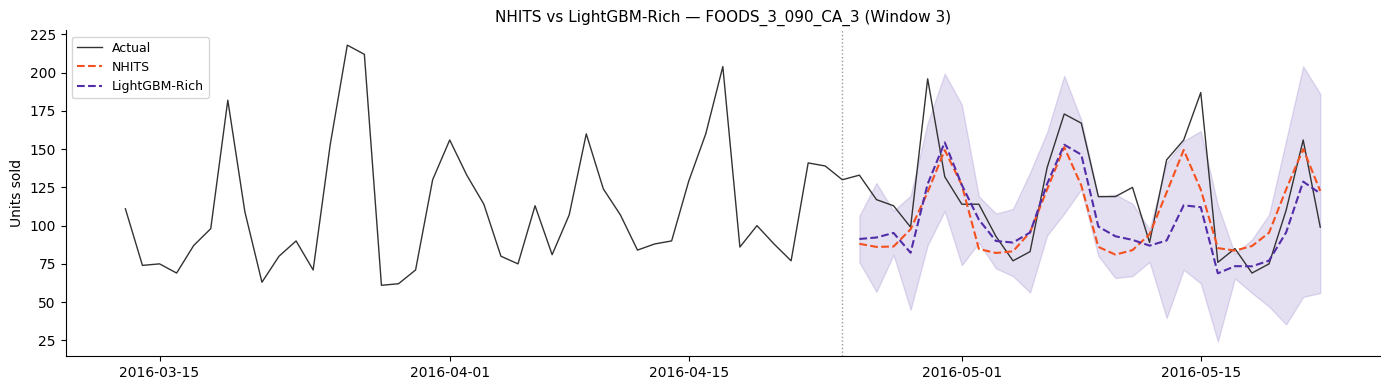

In [32]:
if dl_micro_validated is not None:
    sample_uid = top_series[0]
    sample_cut = dl_micro_validated["cutoff"].unique()[-1]

    try:
        ml_micro_df = pd.read_parquet(ARTIFACT_DIR / "05_ml_rich_micro_forecasts.parquet")
        combined = pd.concat(
            [dl_micro_validated, ml_micro_df[ml_micro_df["model"] == "LightGBM-Rich"]],
            ignore_index=True,
        )
        models = ["NHITS", "LightGBM-Rich"]
    except Exception:
        combined = dl_micro_validated
        models = ["NHITS"]

    plot_forecast_overlay(
        actuals_df=panel,
        forecasts_df=combined,
        unique_id=sample_uid,
        cutoff=sample_cut,
        models=models,
        title=f"NHITS vs LightGBM-Rich — {sample_uid} (Window 3)",
    )
else:
    print("Green Path not available — plot skipped. Visual comparison available in Module 8.")

**Expected output (if Green Path succeeded):** NHITS forecast with shaded 80% interval, LightGBM dotted overlay, actuals in dark gray.

---
## 6.9 — Score the Micro DL Forecasts
**[Watch Only]**

---

In [33]:
if dl_micro_validated is not None:
    dl_micro_scores = score_forecasts(dl_micro_validated, subset_name=f"micro_{MICRO_SUBSET_N}")

    leaderboard_micro = build_leaderboard([dl_micro_scores])
    display_cols   = ["model", "wMAPE", "Bias", "IntervalScore_80"]
    available_cols = [c for c in display_cols if c in leaderboard_micro.columns]
    display(leaderboard_micro[available_cols])
else:
    print("Micro scoring skipped — Red Path was taken. Full-subset scores in 6.10.")

,model,wMAPE,Bias
0,NHITS,0.26705,-0.048556


**Expected output (if Green Path succeeded):**
```
   model   wMAPE    Bias  IntervalScore_80
   NHITS  0.XXXX  0.XXXX               NaN
```
`IntervalScore_80` is NaN for the micro run — the CV in 6.6 omits `prediction_intervals` to stay within the 90-second runtime ceiling. Full-subset conformal intervals are in the precomputed artifact (6.10).

---
## 6.10 — Load Full-Subset DL Forecasts and Update Leaderboard
**[Watch Only]**

---

In [34]:
# 🔴 RED PATH (standard) — always load precomputed full-subset DL forecasts
dl_full = load_checkpoint("06_dl_forecasts")

dl_full_scores       = score_forecasts(dl_full,       subset_name=f"workshop_{WORKSHOP_SUBSET_N}")
baseline_full        = load_checkpoint("04_baseline_forecasts")
baseline_full_scores = score_forecasts(baseline_full, subset_name=f"workshop_{WORKSHOP_SUBSET_N}")
ml_full              = load_checkpoint("05_ml_forecasts")
ml_full_scores       = score_forecasts(ml_full,       subset_name=f"workshop_{WORKSHOP_SUBSET_N}")

leaderboard_6 = build_leaderboard([baseline_full_scores, ml_full_scores, dl_full_scores])

display_cols   = ["model", "wMAPE", "Bias", "IntervalScore_80"]
available_cols = [c for c in display_cols if c in leaderboard_6.columns]
wmape_lb = leaderboard_6[available_cols].dropna(subset=["wMAPE"]).sort_values("wMAPE")
wmape_lb


  ✓ RED PATH RECOVERY COMPLETE
    Artifact : 06_dl_forecasts
    File     : 06_dl_forecasts.parquet
    Rows     : 84,000


  ✓ RED PATH RECOVERY COMPLETE
    Artifact : 04_baseline_forecasts
    File     : 04_baseline_forecasts.parquet
    Rows     : 336,000


  ✓ RED PATH RECOVERY COMPLETE
    Artifact : 05_ml_forecasts
    File     : 05_ml_forecasts.parquet
    Rows     : 84,000



,model,wMAPE,Bias,IntervalScore_80
0,NHITS,0.438445,-0.101875,26.606782
1,LightGBM,0.465202,0.018044,25.613683
2,AutoETS,0.474567,0.000437,27.304706
3,Chronos-t5-mini,0.492306,-0.169574,27.208518
4,SeasonalNaive,0.558018,-0.025829,32.260679
5,Naive,0.665166,0.169000,38.207417


**Expected output:** Leaderboard sorted by wMAPE — NHITS and LightGBM competing at the top, baselines below.

---
## 6.11 — Save the Micro DL Artifact
**[Watch Only]**

---

In [35]:
if dl_micro_validated is not None:
    micro_dl_path = ARTIFACT_DIR / "06_dl_micro_forecasts.parquet"
    dl_micro_validated.to_parquet(micro_dl_path, index=False)
    print(f"  ✓ Micro DL artifact saved : {micro_dl_path.name} ({len(dl_micro_validated):,} rows)")
print(f"  ✓ Full DL artifact loaded : 06_dl_forecasts.parquet ({len(dl_full):,} rows)")

  ✓ Micro DL artifact saved : 06_dl_micro_forecasts.parquet (4,200 rows)
  ✓ Full DL artifact loaded : 06_dl_forecasts.parquet (84,000 rows)
